正在运行 1/3: 基础 Swap 算法...
正在运行 2/3: 2-opt Swap 算法...
正在运行 3/3: 模拟退火算法 (可能需要几秒钟)...


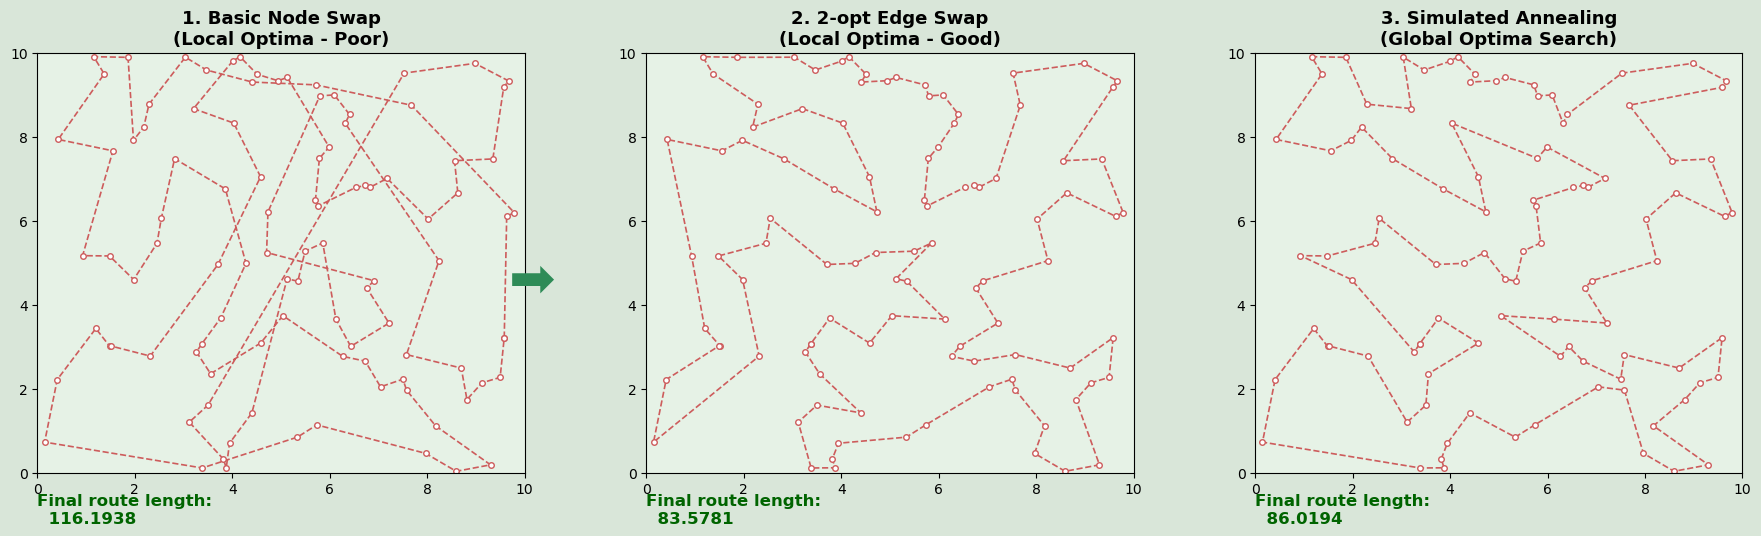

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

# ==========================================
# 1. 初始化参数与生成模拟数据
# ==========================================
NUM_CITIES = 100  # 100个城市节点
GRID_SIZE = 10.0  # 坐标系范围 0-10
np.random.seed(35)  # 设置随机种子以保证每次运行初始状态完全一致

# 随机生成城市坐标 (x, y)
cities = np.random.rand(NUM_CITIES, 2) * GRID_SIZE

# 预计算距离矩阵 (大幅提升计算速度)
dist_matrix = np.linalg.norm(cities[:, np.newaxis] - cities, axis=2)


def calc_total_dist(tour):
    """根据距离矩阵计算总路径长度"""
    return sum(dist_matrix[tour[i], tour[(i + 1) % NUM_CITIES]] for i in range(NUM_CITIES))


# 生成一个共同的初始随机路径，确保三个算法起点完全一致
initial_tour = list(range(NUM_CITIES))
np.random.shuffle(initial_tour)


# ==========================================
# 2. 基础 Swap 算法 (Node Swap - 交换两个节点)
# ==========================================
def basic_swap_tsp(tour):
    curr_tour = copy.deepcopy(tour)
    curr_dist = calc_total_dist(curr_tour)
    improved = True

    while improved:
        improved = False
        for i in range(NUM_CITIES - 1):
            for j in range(i + 1, NUM_CITIES):
                new_tour = curr_tour[:]
                new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
                new_dist = calc_total_dist(new_tour)

                if new_dist < curr_dist:
                    curr_tour = new_tour
                    curr_dist = new_dist
                    improved = True
                    break
            if improved:
                break
    return curr_tour, curr_dist


# ==========================================
# 3. 2-opt Swap 算法 (Edge Swap - 反转一段路径)
# ==========================================
def two_opt_swap_tsp(tour):
    curr_tour = copy.deepcopy(tour)
    curr_dist = calc_total_dist(curr_tour)
    improved = True

    while improved:
        improved = False
        for i in range(NUM_CITIES - 1):
            for j in range(i + 2, NUM_CITIES):
                n1, n2 = curr_tour[i], curr_tour[i + 1]
                n3, n4 = curr_tour[j], curr_tour[(j + 1) % NUM_CITIES]

                d_old = dist_matrix[n1, n2] + dist_matrix[n3, n4]
                d_new = dist_matrix[n1, n3] + dist_matrix[n2, n4]

                if d_new < d_old:
                    curr_tour[i + 1: j + 1] = reversed(curr_tour[i + 1: j + 1])
                    curr_dist = curr_dist - d_old + d_new
                    improved = True
                    break
            if improved:
                break
    return curr_tour, calc_total_dist(curr_tour)


# ==========================================
# 4. 模拟退火算法 (Simulated Annealing)
# ==========================================
def simulated_annealing_tsp(tour):
    curr_tour = copy.deepcopy(tour)
    curr_dist = calc_total_dist(curr_tour)

    best_tour = copy.deepcopy(curr_tour)
    best_dist = curr_dist

    # 退火参数设置
    T = 100.0  # 初始温度
    T_min = 0.001  # 终止温度
    alpha = 0.99  # 降温系数

    while T > T_min:
        # 在当前温度下进行多次迭代 (内循环)
        for _ in range(100):
            # 随机选择一段路径进行 2-opt 反转尝试
            i = np.random.randint(0, NUM_CITIES - 1)
            j = np.random.randint(i + 2, NUM_CITIES + (1 if i > 0 else 0))
            if j >= NUM_CITIES: j = NUM_CITIES - 1

            n1, n2 = curr_tour[i], curr_tour[i + 1]
            n3, n4 = curr_tour[j], curr_tour[(j + 1) % NUM_CITIES]

            d_old = dist_matrix[n1, n2] + dist_matrix[n3, n4]
            d_new = dist_matrix[n1, n3] + dist_matrix[n2, n4]
            delta = d_new - d_old

            # Metropolis 准则：如果更好则接受；如果更差，以一定概率接受
            if delta < 0 or math.exp(-delta / T) > np.random.random():
                curr_tour[i + 1: j + 1] = reversed(curr_tour[i + 1: j + 1])
                curr_dist += delta

                # 记录全局最优解
                if curr_dist < best_dist:
                    best_tour = copy.deepcopy(curr_tour)
                    best_dist = curr_dist

        T *= alpha  # 降温

    return best_tour, calc_total_dist(best_tour)


# ==========================================
# 5. 运行算法
# ==========================================
print("正在运行 1/3: 基础 Swap 算法...")
tour_basic, dist_basic = basic_swap_tsp(initial_tour)

print("正在运行 2/3: 2-opt Swap 算法...")
tour_2opt, dist_2opt = two_opt_swap_tsp(initial_tour)

print("正在运行 3/3: 模拟退火算法 (可能需要几秒钟)...")
tour_sa, dist_sa = simulated_annealing_tsp(initial_tour)


# ==========================================
# 6. 可视化对比结果
# ==========================================
def plot_tour(ax, tour, title, distance):
    plot_t = tour + [tour[0]]
    x = [cities[i][0] for i in plot_t]
    y = [cities[i][1] for i in plot_t]

    ax.plot(x, y, linestyle='--', marker='o', color='indianred',
            markerfacecolor='white', markersize=4, linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_xticks(range(0, 11, 2))
    ax.set_yticks(range(0, 11, 2))
    ax.set_facecolor('#e6f2e6')

    ax.text(0, -1.2, f'Final route length:\n  {distance:.4f}',
            fontsize=12, color='darkgreen', fontweight='bold')


# 创建 1x3 的子图窗口
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor('#d9e6d9')

plot_tour(axes[0], tour_basic, '1. Basic Node Swap\n(Local Optima - Poor)', dist_basic)
plot_tour(axes[1], tour_2opt, '2. 2-opt Edge Swap\n(Local Optima - Good)', dist_2opt)
plot_tour(axes[2], tour_sa, '3. Simulated Annealing\n(Global Optima Search)', dist_sa)

# 添加箭头
fig.text(0.35, 0.5, '➡', ha='center', va='center', fontsize=40, color='#2e8b57')


plt.subplots_adjust(bottom=0.18, wspace=0.25)
plt.show()